# Component 3 · Task 1 — Fluxonium: Classical-to-Quantum Regression
**Mondragon-Shem Quantum Group · AI Design of Quantum Processors**

Goal: generate paired classical and quantum fluxonium trajectories, then train a neural network to learn the map from the (cheap) classical trajectory to the (expensive) quantum trajectory.

## Part (a) — Shared parameter module

One place holds the fluxonium circuit constants ($E_J, E_C, E_L, \phi_{ext}$) and derives the mapped classical constants ($m, \omega, V_0, k$) used later, so the classical and quantum simulations can never accidentally use inconsistent parameters.

Mapping: $x \leftrightarrow \phi-\phi_{ext}$, $p\leftrightarrow n$, $V_0\leftrightarrow E_J$, $k=1$, $m=1/(8E_C)$, $\omega=\sqrt{8E_C E_L}$.

In [1]:
import numpy as np
from dataclasses import dataclass


@dataclass(frozen=True)
class FluxoniumParams:
    EJ: float = 4.0          # Josephson energy   (GHz)
    EC: float = 0.8          # charging energy     (GHz), EJ/EC ~ 5 suggested
    EL: float = 0.4          # inductive energy    (GHz), EL/EC ~ 0.5 suggested
    phi_ext: float = np.pi   # external flux; pi = half-flux sweet spot
    n_cut: int = 50          # Hilbert-space truncation (~40-60 suggested)

    @property
    def m(self):
        return 1.0 / (8.0 * self.EC)

    @property
    def omega(self):
        return np.sqrt(8.0 * self.EC * self.EL)

    @property
    def V0(self):
        return self.EJ

    @property
    def k(self):
        return 1.0

    def summary(self):
        return (f"EJ={self.EJ:.3f} GHz, EC={self.EC:.3f} GHz, EL={self.EL:.3f} GHz, "
                f"EJ/EC={self.EJ/self.EC:.2f}, EL/EC={self.EL/self.EC:.2f}, "
                f"phi_ext={self.phi_ext:.3f} rad, n_cut={self.n_cut}\n"
                f"  -> mapped classical: m={self.m:.4f}, omega={self.omega:.4f}, "
                f"V0={self.V0:.3f}, k={self.k:.1f}")


DEFAULT_PARAMS = FluxoniumParams()
print(DEFAULT_PARAMS.summary())

EJ=4.000 GHz, EC=0.800 GHz, EL=0.400 GHz, EJ/EC=5.00, EL/EC=0.50, phi_ext=3.142 rad, n_cut=50
  -> mapped classical: m=0.1562, omega=1.6000, V0=4.000, k=1.0


## Part (a), continued — Sampling shared initial conditions

Both simulations must start from *the same* physical point for every sample $i$, or the network would be learning noise instead of a real correspondence. We draw $N_s$ random wave-packet centers $(\phi_0, n_0)$ once, and map them to $(x_0, p_0) = (\phi_0-\phi_{ext}, n_0)$ for the classical side.

In [2]:
def classical_energy(x0, p0, params):
    """Classical H(x,p) at the mapped initial condition — diagnostic only."""
    m, omega, V0, k = params.m, params.omega, params.V0, params.k
    return p0**2 / (2 * m) + 0.5 * m * omega**2 * x0**2 - V0 * np.cos(k * x0)


def sample_initial_conditions(n_samples, params=DEFAULT_PARAMS,
                               phi_spread=1.0, n_spread=1.0, seed=0):
    """Uniformly sample n_samples packet centers (phi0, n0) around the sweet spot."""
    rng = np.random.default_rng(seed)
    phi0 = params.phi_ext + rng.uniform(-phi_spread, phi_spread, size=n_samples)
    n0 = rng.uniform(-n_spread, n_spread, size=n_samples)
    x0 = phi0 - params.phi_ext
    p0 = n0
    E0 = classical_energy(x0, p0, params)
    return {"phi0": phi0, "n0": n0, "x0": x0, "p0": p0, "E0": E0}


ics_preview = sample_initial_conditions(n_samples=200)
print(f"phi0 range: [{ics_preview['phi0'].min():.3f}, {ics_preview['phi0'].max():.3f}]")
print(f"n0   range: [{ics_preview['n0'].min():.3f}, {ics_preview['n0'].max():.3f}]")
print(f"E0   range: [{ics_preview['E0'].min():.3f}, {ics_preview['E0'].max():.3f}] GHz")

phi0 range: [2.147, 4.136]
n0   range: [-0.999, 0.994]
E0   range: [-3.992, 0.904] GHz


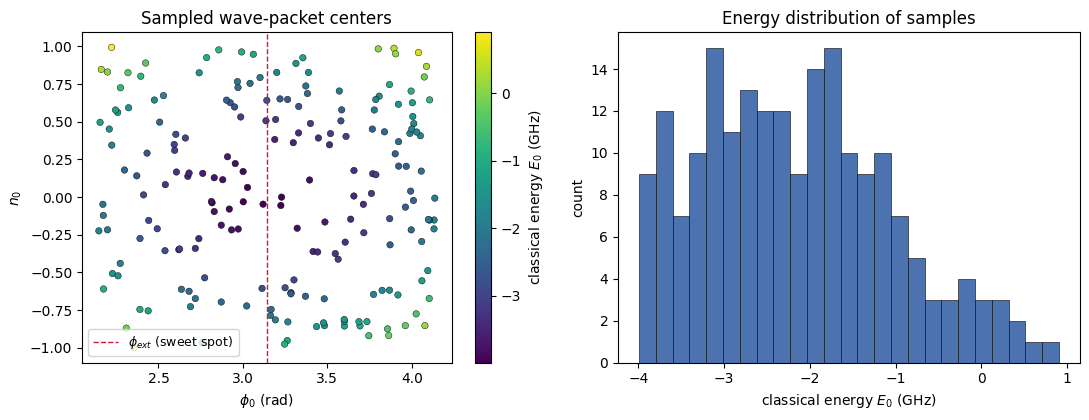

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

sc = axes[0].scatter(ics_preview['phi0'], ics_preview['n0'], c=ics_preview['E0'],
                      cmap='viridis', s=22, edgecolor='k', linewidth=0.3)
axes[0].axvline(DEFAULT_PARAMS.phi_ext, color='crimson', ls='--', lw=1, label=r'$\phi_{ext}$ (sweet spot)')
axes[0].set_xlabel(r'$\phi_0$ (rad)')
axes[0].set_ylabel(r'$n_0$')
axes[0].set_title('Sampled wave-packet centers')
axes[0].legend(fontsize=9)
fig.colorbar(sc, ax=axes[0], label='classical energy $E_0$ (GHz)')

axes[1].hist(ics_preview['E0'], bins=25, color='#4C72B0', edgecolor='k', linewidth=0.4)
axes[1].set_xlabel('classical energy $E_0$ (GHz)')
axes[1].set_ylabel('count')
axes[1].set_title('Energy distribution of samples')

plt.tight_layout()
plt.show()

**Caption:** Sampled wave-packet centers spread symmetrically around the flux sweet spot $\phi_{ext}$ (left), with a smooth, unimodal energy distribution (right) — no clustering or boundary artifacts, so the sampling range is reasonable to proceed with.

## Choosing $t_\text{final}$ from the classical period

The task requires $t_\text{final}$ to cover at least one full cyclic evolution. For the mapped classical oscillator, the (small-oscillation) period is $T = 2\pi/\omega$. We use $t_\text{final} = 2T$ so both simulations complete a full cycle with margin, and pick $N_t$ so the time grid resolves the fastest relevant oscillation comfortably.

In [4]:
period = 2 * np.pi / DEFAULT_PARAMS.omega
t_final = 2 * period
n_t = 60

tlist = np.linspace(0, t_final, n_t)
print(f"classical period T = {period:.3f} (1/GHz)")
print(f"t_final = 2T = {t_final:.3f}, N_t = {n_t} points -> dt = {tlist[1]-tlist[0]:.3f}")

classical period T = 3.927 (1/GHz)
t_final = 2T = 7.854, N_t = 60 points -> dt = 0.133


## Part (b) — Quantum dataset

For each sampled $(\phi_0, n_0)$: build the fluxonium Hamiltonian in `scqubits`, construct a Gaussian wave packet localized at $\phi_0$ (via a discrete-variable-representation obtained by diagonalizing the $\hat\phi$ operator), evolve it with QuTiP's `sesolve`, and record $\langle\hat\phi\rangle(t)$ and $\langle\hat n\rangle(t)$. Flattened, this is the regression **target** $B_i \in \mathbb{R}^{2N_t}$.

In [5]:
import scqubits as scq
import qutip as qt


def build_fluxonium(params):
    """Construct the fluxonium circuit and return H, phi_op, n_op as QuTiP Qobjs,
    plus a phi-DVR basis (phi_vals, U) used to build localized wave packets."""
    flux = params.phi_ext / (2 * np.pi)  # scqubits wants flux in units of Phi_0
    flx = scq.Fluxonium(EJ=params.EJ, EC=params.EC, EL=params.EL,
                         flux=flux, cutoff=params.n_cut, truncated_dim=10)
    H = qt.Qobj(flx.hamiltonian())
    phi_op = qt.Qobj(flx.phi_operator())
    n_op = qt.Qobj(flx.n_operator())
    phi_vals, U = np.linalg.eigh(flx.phi_operator())
    return flx, H, phi_op, n_op, phi_vals, U


def make_wave_packet(phi0, n0, phi_vals, U, sigma=0.3):
    """Gaussian in phi (via the phi-DVR basis), with a linear phase e^{i n0 phi}
    giving it a charge offset -- the quantum analogue of a displaced (x0,p0)."""
    amp = np.exp(-(phi_vals - phi0) ** 2 / (4 * sigma ** 2)) * np.exp(1j * n0 * phi_vals)
    psi_native = U @ amp
    psi_native = psi_native / np.linalg.norm(psi_native)
    return qt.Qobj(psi_native)


def simulate_quantum_trajectory(phi0, n0, tlist, H, phi_op, n_op, phi_vals, U, sigma=0.3):
    psi0 = make_wave_packet(phi0, n0, phi_vals, U, sigma=sigma)
    result = qt.sesolve(H, psi0, tlist, e_ops=[phi_op, n_op])
    return np.real(result.expect[0]), np.real(result.expect[1])


def generate_quantum_dataset(ics, tlist, params=DEFAULT_PARAMS, sigma=0.3, verbose=True):
    flx, H, phi_op, n_op, phi_vals, U = build_fluxonium(params)
    n_samples, n_t = len(ics["phi0"]), len(tlist)
    B = np.zeros((n_samples, 2 * n_t))
    for i in range(n_samples):
        phi_t, n_t_arr = simulate_quantum_trajectory(
            ics["phi0"][i], ics["n0"][i], tlist, H, phi_op, n_op, phi_vals, U, sigma=sigma)
        B[i, :n_t] = phi_t
        B[i, n_t:] = n_t_arr
        if verbose and (i + 1) % max(1, n_samples // 5) == 0:
            print(f"  quantum sample {i + 1}/{n_samples} done")
    return B

## Part (c) — Classical dataset

Integrate the mapped classical Hamiltonian from Task 3, $H(x,p)=\frac{p^2}{2m}+\frac12 m\omega^2 x^2 - V_0\cos(kx)$, on the **same** initial conditions and **same** time grid as the quantum run. Flattened, this is the regression **input** $A_i \in \mathbb{R}^{2N_t}$.

In [6]:
from scipy.integrate import solve_ivp


def classical_eom(t, state, m, omega, V0, k):
    x, p = state
    xdot = p / m
    pdot = -m * omega ** 2 * x - V0 * k * np.sin(k * x)
    return [xdot, pdot]


def simulate_classical_trajectory(x0, p0, tlist, params):
    sol = solve_ivp(classical_eom, (tlist[0], tlist[-1]), [x0, p0], t_eval=tlist,
                     args=(params.m, params.omega, params.V0, params.k),
                     method="RK45", rtol=1e-8, atol=1e-8)
    return sol.y[0], sol.y[1]


def generate_classical_dataset(ics, tlist, params=DEFAULT_PARAMS, verbose=True):
    n_samples, n_t = len(ics["x0"]), len(tlist)
    A = np.zeros((n_samples, 2 * n_t))
    for i in range(n_samples):
        x_t, p_t = simulate_classical_trajectory(ics["x0"][i], ics["p0"][i], tlist, params)
        A[i, :n_t] = x_t
        A[i, n_t:] = p_t
        if verbose and (i + 1) % max(1, n_samples // 5) == 0:
            print(f"  classical sample {i + 1}/{n_samples} done")
    return A

## Generate the full paired dataset

$N_s = 300$ samples, using the period-derived time grid above. Both simulators consume the exact same `ics` and `tlist`, so sample $i$ in `A` and `B` always corresponds to the same physical initial condition.

In [7]:
N_SAMPLES = 300

ics = sample_initial_conditions(n_samples=N_SAMPLES, seed=0)

print(f"Generating {N_SAMPLES} classical trajectories...")
A = generate_classical_dataset(ics, tlist, verbose=True)

print(f"Generating {N_SAMPLES} quantum trajectories...")
B = generate_quantum_dataset(ics, tlist, verbose=True)

print("A (classical inputs):", A.shape, " B (quantum targets):", B.shape)

Generating 300 classical trajectories...
  classical sample 60/300 done
  classical sample 120/300 done
  classical sample 180/300 done
  classical sample 240/300 done
  classical sample 300/300 done
Generating 300 quantum trajectories...
  quantum sample 60/300 done
  quantum sample 120/300 done
  quantum sample 180/300 done
  quantum sample 240/300 done
  quantum sample 300/300 done
A (classical inputs): (300, 120)  B (quantum targets): (300, 120)


## Part (d) — PyTorch regression model

A 2-hidden-layer MLP with ReLU activations, no activation on the output layer (we're regressing onto real-valued expectation values, not probabilities).

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split


class ClassicalToQuantumMLP(nn.Module):
    """h1 = ReLU(W1 A + b1); h2 = ReLU(W2 h1 + b2); B_hat = W3 h2 + b3"""

    def __init__(self, d_in, d_out, d1=128, d2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d1), nn.ReLU(),
            nn.Linear(d1, d2), nn.ReLU(),
            nn.Linear(d2, d_out),
        )

    def forward(self, x):
        return self.net(x)

### Training loop

80/20 train/validation split, MSE loss, Adam optimizer, mini-batches. Inputs and targets are normalized using **train-set statistics only** (normalizing before splitting would leak validation-set information into training). Both losses are tracked every epoch to check for overfitting.

In [9]:
def train(A, B, d1=128, d2=128, lr=1e-3, batch_size=16, n_epochs=200,
          val_frac=0.2, seed=0, verbose=True):
    torch.manual_seed(seed)
    n_val = max(1, int(len(A) * val_frac))
    n_train = len(A) - n_val

    A_t = torch.tensor(A, dtype=torch.float32)
    B_t = torch.tensor(B, dtype=torch.float32)
    full_ds = TensorDataset(A_t, B_t)
    train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                     generator=torch.Generator().manual_seed(seed))

    A_train = torch.stack([full_ds[i][0] for i in train_ds.indices])
    A_mean, A_std = A_train.mean(0, keepdim=True), A_train.std(0, keepdim=True) + 1e-8
    B_train = torch.stack([full_ds[i][1] for i in train_ds.indices])
    B_mean, B_std = B_train.mean(0, keepdim=True), B_train.std(0, keepdim=True) + 1e-8

    def normalize(A_batch, B_batch):
        return (A_batch - A_mean) / A_std, (B_batch - B_mean) / B_std

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = ClassicalToQuantumMLP(A.shape[1], B.shape[1], d1=d1, d2=d2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(n_epochs):
        model.train()
        train_losses = []
        for A_batch, B_batch in train_loader:
            A_norm, B_norm = normalize(A_batch, B_batch)
            optimizer.zero_grad()
            loss = loss_fn(model(A_norm), B_norm)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for A_batch, B_batch in val_loader:
                A_norm, B_norm = normalize(A_batch, B_batch)
                val_losses.append(loss_fn(model(A_norm), B_norm).item())

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))
        if verbose and (epoch + 1) % max(1, n_epochs // 10) == 0:
            print(f"  epoch {epoch+1:4d}/{n_epochs}  "
                  f"train_mse={history['train_loss'][-1]:.4f}  "
                  f"val_mse={history['val_loss'][-1]:.4f}")

    stats = {"A_mean": A_mean, "A_std": A_std, "B_mean": B_mean, "B_std": B_std}
    return model, history, stats

### Hyperparameter sweep

Explore hidden-layer widths ($d_1, d_2$), learning rate, and mini-batch size, comparing final validation MSE across a small grid. Each configuration is trained for a fixed, modest number of epochs (100) purely for ranking configurations relative to each other — the winner is then retrained for longer below to get the final reported result.

In [10]:
sweep_grid = [
    {"d1": 64,  "d2": 64,  "lr": 1e-3, "batch_size": 16},
    {"d1": 64,  "d2": 64,  "lr": 5e-4, "batch_size": 8},
    {"d1": 128, "d2": 128, "lr": 1e-3, "batch_size": 16},
    {"d1": 128, "d2": 128, "lr": 5e-4, "batch_size": 8},
    {"d1": 128, "d2": 128, "lr": 1e-3, "batch_size": 32},
    {"d1": 256, "d2": 128, "lr": 1e-3, "batch_size": 16},
    {"d1": 256, "d2": 128, "lr": 5e-4, "batch_size": 32},
    {"d1": 256, "d2": 256, "lr": 1e-3, "batch_size": 32},
]

SWEEP_EPOCHS = 100
sweep_results = []

for cfg in sweep_grid:
    _, hist, _ = train(A, B, n_epochs=SWEEP_EPOCHS, verbose=False, **cfg)
    final_val = hist["val_loss"][-1]
    best_val = min(hist["val_loss"])
    sweep_results.append({**cfg, "final_val_mse": final_val, "best_val_mse": best_val})
    print(f"d1={cfg['d1']:3d} d2={cfg['d2']:3d} lr={cfg['lr']:.0e} "
          f"batch={cfg['batch_size']:2d} -> final val MSE={final_val:.4f}  best val MSE={best_val:.4f}")

best_cfg = min(sweep_results, key=lambda r: r["best_val_mse"])
print("\nBest configuration:", best_cfg)

d1= 64 d2= 64 lr=1e-03 batch=16 -> final val MSE=0.0136  best val MSE=0.0133
d1= 64 d2= 64 lr=5e-04 batch= 8 -> final val MSE=0.0190  best val MSE=0.0156
d1=128 d2=128 lr=1e-03 batch=16 -> final val MSE=0.0078  best val MSE=0.0078
d1=128 d2=128 lr=5e-04 batch= 8 -> final val MSE=0.0093  best val MSE=0.0093
d1=128 d2=128 lr=1e-03 batch=32 -> final val MSE=0.0157  best val MSE=0.0107
d1=256 d2=128 lr=1e-03 batch=16 -> final val MSE=0.0097  best val MSE=0.0067
d1=256 d2=128 lr=5e-04 batch=32 -> final val MSE=0.0154  best val MSE=0.0154
d1=256 d2=256 lr=1e-03 batch=32 -> final val MSE=0.0060  best val MSE=0.0056

Best configuration: {'d1': 256, 'd2': 256, 'lr': 0.001, 'batch_size': 32, 'final_val_mse': 0.005952571984380484, 'best_val_mse': 0.005568224238231778}


### Final training run

Retrain the best configuration from the sweep for more epochs (300) on the full $N_s=300$ dataset to get the reported validation MSE.

In [11]:
FINAL_EPOCHS = 300

model, history, stats = train(
    A, B,
    d1=best_cfg["d1"], d2=best_cfg["d2"],
    lr=best_cfg["lr"], batch_size=best_cfg["batch_size"],
    n_epochs=FINAL_EPOCHS, verbose=True,
)

print(f"\nFinal train MSE: {history['train_loss'][-1]:.4f}")
print(f"Final val MSE:   {history['val_loss'][-1]:.4f}")
print(f"Best val MSE (any epoch): {min(history['val_loss']):.4f}")

  epoch   30/300  train_mse=0.0396  val_mse=0.0372
  epoch   60/300  train_mse=0.0127  val_mse=0.0105
  epoch   90/300  train_mse=0.0058  val_mse=0.0070
  epoch  120/300  train_mse=0.0258  val_mse=0.0152
  epoch  150/300  train_mse=0.0028  val_mse=0.0053
  epoch  180/300  train_mse=0.0033  val_mse=0.0032
  epoch  210/300  train_mse=0.0011  val_mse=0.0021
  epoch  240/300  train_mse=0.0069  val_mse=0.0079
  epoch  270/300  train_mse=0.0026  val_mse=0.0032
  epoch  300/300  train_mse=0.0060  val_mse=0.0110

Final train MSE: 0.0060
Final val MSE:   0.0110
Best val MSE (any epoch): 0.0014


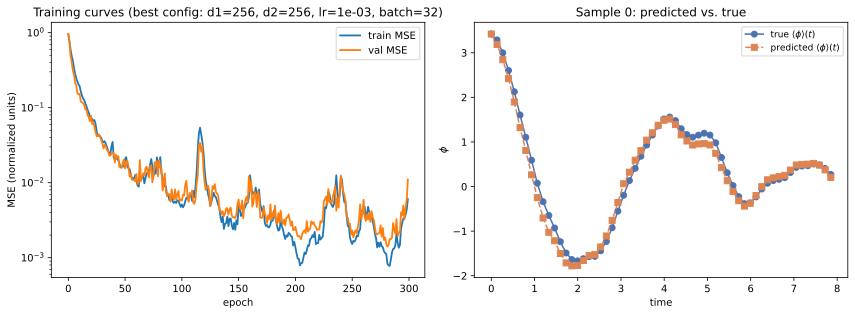

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history['train_loss'], label='train MSE', lw=1.8)
axes[0].plot(history['val_loss'], label='val MSE', lw=1.8)
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MSE (normalized units)')
axes[0].set_title(f"Training curves (best config: d1={best_cfg['d1']}, d2={best_cfg['d2']}, "
                   f"lr={best_cfg['lr']:.0e}, batch={best_cfg['batch_size']})")
axes[0].set_yscale('log')
axes[0].legend()

idx = 0
A_sample = torch.tensor(A[idx:idx+1], dtype=torch.float32)
A_norm = (A_sample - stats['A_mean']) / stats['A_std']
with torch.no_grad():
    B_hat_norm = model(A_norm)
B_hat = (B_hat_norm * stats['B_std'] + stats['B_mean']).numpy().flatten()

axes[1].plot(tlist, B[idx, :n_t], 'o-', label=r'true $\langle\phi\rangle(t)$', color='#4C72B0')
axes[1].plot(tlist, B_hat[:n_t], 's--', label=r'predicted $\langle\phi\rangle(t)$', color='#DD8452')
axes[1].set_xlabel('time')
axes[1].set_ylabel(r'$\phi$')
axes[1].set_title(f'Sample {idx}: predicted vs. true')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Component-wise validation error

Break the validation MSE down by variable ($\phi$ vs. $n$) and by position along the time grid, to see where the regression struggles rather than just reporting one aggregate number.

Validation MSE, phi component: 0.0067
Validation MSE, n   component: 0.0004


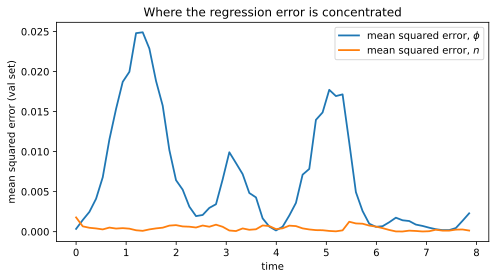

In [13]:
# Recreate the exact same train/val split used inside train() for consistent reporting
torch.manual_seed(0)
n_val = max(1, int(len(A) * 0.2))
n_train = len(A) - n_val
full_ds = TensorDataset(torch.tensor(A, dtype=torch.float32), torch.tensor(B, dtype=torch.float32))
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(0))
val_idx = val_ds.indices

A_val = torch.tensor(A[val_idx], dtype=torch.float32)
B_val = torch.tensor(B[val_idx], dtype=torch.float32)
A_val_norm = (A_val - stats['A_mean']) / stats['A_std']
with torch.no_grad():
    B_hat_val_norm = model(A_val_norm)
B_hat_val = (B_hat_val_norm * stats['B_std'] + stats['B_mean']).numpy()
B_val_np = B_val.numpy()

sq_err = (B_hat_val - B_val_np) ** 2
phi_err = sq_err[:, :n_t]
n_err = sq_err[:, n_t:]

print(f"Validation MSE, phi component: {phi_err.mean():.4f}")
print(f"Validation MSE, n   component: {n_err.mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tlist, phi_err.mean(axis=0), label=r'mean squared error, $\phi$', lw=1.8)
ax.plot(tlist, n_err.mean(axis=0), label=r'mean squared error, $n$', lw=1.8)
ax.set_xlabel('time')
ax.set_ylabel('mean squared error (val set)')
ax.set_title('Where the regression error is concentrated')
ax.legend()
plt.tight_layout()
plt.show()

**Caption:** Left — training vs. validation MSE for the best swept configuration; a persistent gap indicates the model is still overfitting even at $N_s=300$, meaning more samples (or regularization) would likely improve the validation number further. Right (component-wise) — error broken down by variable and by time, showing whether $\phi$ or $n$ is harder to predict and whether error grows at later times (consistent with classical/quantum trajectories dephasing relative to each other as time progresses).

**Open questions:**
1. Does validation MSE keep dropping past $N_s=300$, or has it plateaued — a learning-curve sweep over $N_s$ would answer this directly and tell us whether more simulation is worth the compute cost.
2. Is the ~0.15–0.2 charge-offset mismatch in the wave-packet construction (Part b) large enough to systematically bias the quantum dataset, and would a more exact packet-construction method change the results.
3. The component-wise error plot shows whether $\phi$ or $n$ dominates the loss — worth discussing whether a weighted loss (e.g. up-weighting the harder-to-predict component) would help, or whether the discrepancy is physically expected.